<a href="https://colab.research.google.com/github/sanskar-paudel/AI-ML-Resume-Screening-Ranking-System/blob/main/AI_Resume_ML_Ranking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q pandas numpy scikit-learn sentence-transformers xgboost

In [ ]:
import pandas
import numpy
import sklearn
import sentence_transformers
import xgboost

print("Setup successful")

Setup successful


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/AI_Resume_Screening"

In [ ]:
import os

os.makedirs(f"{PROJECT_PATH}/data/raw", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/data/processed", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/data/labels", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/models", exist_ok=True)
os.makedirs(f"{PROJECT_PATH}/results", exist_ok=True)

In [ ]:
FEATURE_NAMES = [
    "semantic_similarity",
    "required_skill_coverage",
    "preferred_skill_coverage",
    "experience_match",
    "education_match",
    "project_relevance",
    "certification_relevance",
    "keyword_overlap",
    "tfidf_similarity",
]

RANDOM_SEED = 42

LABELS = [0, 1, 2, 3]

SENTENCE_MODEL = "all-MiniLM-L6-v2"

XGBOOST_OBJECTIVE = "rank:pairwise"

In [ ]:
import pandas as pd


def load_dataset(path):
    return pd.read_csv(path)


def validate_dataset(df):
    required_columns = [
        "job_id",
        "candidate_id",
        "resume_text",
        "job_text",
        "relevance_label"
    ]

    missing = [column for column in required_columns if column not in df.columns]

    if missing:
        raise ValueError(f"Missing columns: {missing}")

    if not df["relevance_label"].isin([0, 1, 2, 3]).all():
        raise ValueError("Labels must be 0, 1, 2, or 3")

    return df

In [ ]:
test_data = pd.DataFrame({
    "job_id": ["J001"],
    "candidate_id": ["C001"],
    "resume_text": ["Python developer"],
    "job_text": ["Python developer required"],
    "relevance_label": [3]
})

validate_dataset(test_data)

print("Dataset validation successful")

Dataset validation successful


In [ ]:
DATASET_PATH = f"{PROJECT_PATH}/data/raw/ranking_dataset.csv"

df = pd.read_csv(DATASET_PATH)

df

,job_id,candidate_id,resume_text,job_text,relevance_label
0,J001,C001,"""Python developer with 2 years of experience i...","""Machine Learning Engineer. Requires Python, m...",3
1,J001,C002,"""Frontend developer with 1 year of experience ...","""Machine Learning Engineer. Requires Python, m...",1
2,J001,C003,"""Data analyst with 2 years of experience using...","""Machine Learning Engineer. Requires Python, m...",2


In [ ]:
validate_dataset(df)

print("Dataset validation successful")

Dataset validation successful


In [ ]:
print("Number of jobs:", df["job_id"].nunique())
print("Number of candidates:", df["candidate_id"].nunique())
print("Number of job-candidate pairs:", len(df))

Number of jobs: 1
Number of candidates: 3
Number of job-candidate pairs: 3


In [ ]:
print(df["relevance_label"].value_counts().sort_index())

relevance_label
1    1
2    1
3    1
Name: count, dtype: int64


In [ ]:
group_sizes = df.groupby("job_id").size()

print(group_sizes)

job_id
J001    3
dtype: int64


In [ ]:
CANDIDATES_PATH = f"{PROJECT_PATH}/data/raw/candidates.csv"

candidates_df = pd.read_csv(CANDIDATES_PATH)

candidates_df

,candidate_id,resume_text
0,C001,Python developer with 2 years of experience in...
1,C002,Full stack developer with 3 years of experienc...
2,C003,Data scientist with 2 years of experience in P...
3,C004,Python backend developer with 2 years of exper...
4,C005,Data analyst with 2 years of experience in SQL...
5,C006,Frontend developer with 2 years of experience ...
6,C007,Machine learning engineer with 3 years of expe...
7,C008,Software developer with 3 years of experience ...
8,C009,Data scientist with 3 years of experience in s...
9,C010,Software developer with 2 years of experience ...


In [ ]:
JOBS_PATH = f"{PROJECT_PATH}/data/raw/jobs.csv"

jobs_df = pd.read_csv(JOBS_PATH)

jobs_df

,job_id,job_title,job_text
0,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...
1,J002,Data Scientist,We are looking for a Data Scientist with Pytho...
2,J003,Python Developer,We are looking for a Python Developer with str...
3,J004,Full Stack Developer,We are looking for a Full Stack Developer with...
4,J005,Data Analyst,"We are looking for a Data Analyst with SQL, Py..."


In [ ]:
pairs = jobs_df.merge(candidates_df, how="cross")

pairs = pairs[
    [
        "job_id",
        "job_title",
        "job_text",
        "candidate_id",
        "resume_text"
    ]
]

print("Number of candidate-job pairs:", len(pairs))

pairs.head()

Number of candidate-job pairs: 50


,job_id,job_title,job_text,candidate_id,resume_text
0,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...,C001,Python developer with 2 years of experience in...
1,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...,C002,Full stack developer with 3 years of experienc...
2,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...,C003,Data scientist with 2 years of experience in P...
3,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...,C004,Python backend developer with 2 years of exper...
4,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...,C005,Data analyst with 2 years of experience in SQL...


In [ ]:
pairs[pairs["job_id"] == "J001"][["job_id", "candidate_id", "job_title"]]

,job_id,candidate_id,job_title
0,J001,C001,Machine Learning Engineer
1,J001,C002,Machine Learning Engineer
2,J001,C003,Machine Learning Engineer
3,J001,C004,Machine Learning Engineer
4,J001,C005,Machine Learning Engineer
5,J001,C006,Machine Learning Engineer
6,J001,C007,Machine Learning Engineer
7,J001,C008,Machine Learning Engineer
8,J001,C009,Machine Learning Engineer
9,J001,C010,Machine Learning Engineer


In [ ]:
pairs.groupby("job_id").size()

,0
job_id,
J001,10
J002,10
J003,10
J004,10
J005,10


In [ ]:
PAIRS_PATH = f"{PROJECT_PATH}/data/processed/candidate_job_pairs.csv"

pairs.to_csv(PAIRS_PATH, index=False)

print("Candidate-job pairs saved successfully")

Candidate-job pairs saved successfully


In [ ]:
labeled_pairs = pairs.copy()

labeled_pairs["relevance_label"] = None

labeled_pairs.head()

,job_id,job_title,job_text,candidate_id,resume_text,relevance_label
0,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...,C001,Python developer with 2 years of experience in...,None
1,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...,C002,Full stack developer with 3 years of experienc...,None
2,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...,C003,Data scientist with 2 years of experience in P...,None
3,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...,C004,Python backend developer with 2 years of exper...,None
4,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...,C005,Data analyst with 2 years of experience in SQL...,None


In [ ]:
LABELING_PATH = f"{PROJECT_PATH}/data/labels/labeled_pairs.csv"

labeled_pairs.to_csv(LABELING_PATH, index=False)

print("Labeling file created")

Labeling file created


In [ ]:
LABELING_PATH = f"{PROJECT_PATH}/data/labels/labeled_pairs.csv"   #load the labelling files

labeled_pairs = pd.read_csv(LABELING_PATH)

print("Number of pairs:", len(labeled_pairs))

labeled_pairs.head()

Number of pairs: 50


,job_id,job_title,job_text,candidate_id,resume_text,relevance_label
0,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...,C001,Python developer with 2 years of experience in...,NaN
1,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...,C002,Full stack developer with 3 years of experienc...,NaN
2,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...,C003,Data scientist with 2 years of experience in P...,NaN
3,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...,C004,Python backend developer with 2 years of exper...,NaN
4,J001,Machine Learning Engineer,We are looking for a Machine Learning Engineer...,C005,Data analyst with 2 years of experience in SQL...,NaN


In [ ]:
pd.set_option("display.max_colwidth", 200)

labeled_pairs[
    [
        "job_id",
        "job_title",
        "candidate_id",
        "relevance_label"
    ]
]      #inspect 50 mpairs

,job_id,job_title,candidate_id,relevance_label
0,J001,Machine Learning Engineer,C001,NaN
1,J001,Machine Learning Engineer,C002,NaN
2,J001,Machine Learning Engineer,C003,NaN
3,J001,Machine Learning Engineer,C004,NaN
4,J001,Machine Learning Engineer,C005,NaN
5,J001,Machine Learning Engineer,C006,NaN
6,J001,Machine Learning Engineer,C007,NaN
7,J001,Machine Learning Engineer,C008,NaN
8,J001,Machine Learning Engineer,C009,NaN
9,J001,Machine Learning Engineer,C010,NaN


In [ ]:
label_map = {
    "J001": {
        "C001": 2,
        "C002": 0,
        "C003": 3,
        "C004": 1,
        "C005": 2,
        "C006": 0,
        "C007": 3,
        "C008": 0,
        "C009": 3,
        "C010": 1
    },
    "J002": {
        "C001": 2,
        "C002": 0,
        "C003": 3,
        "C004": 1,
        "C005": 3,
        "C006": 0,
        "C007": 2,
        "C008": 0,
        "C009": 3,
        "C010": 1
    },
    "J003": {
        "C001": 3,
        "C002": 1,
        "C003": 1,
        "C004": 3,
        "C005": 1,
        "C006": 0,
        "C007": 3,
        "C008": 1,
        "C009": 1,
        "C010": 2
    },
    "J004": {
        "C001": 0,
        "C002": 3,
        "C003": 0,
        "C004": 1,
        "C005": 0,
        "C006": 3,
        "C007": 0,
        "C008": 3,
        "C009": 0,
        "C010": 2
    },
    "J005": {
        "C001": 2,
        "C002": 0,
        "C003": 3,
        "C004": 0,
        "C005": 3,
        "C006": 0,
        "C007": 2,
        "C008": 0,
        "C009": 3,
        "C010": 1
    }
}

labeled_pairs["relevance_label"] = labeled_pairs.apply(
    lambda row: label_map[row["job_id"]][row["candidate_id"]],
    axis=1
)

labeled_pairs[["job_id", "candidate_id", "relevance_label"]]  #assign relevence label

,job_id,candidate_id,relevance_label
0,J001,C001,2
1,J001,C002,0
2,J001,C003,3
3,J001,C004,1
4,J001,C005,2
5,J001,C006,0
6,J001,C007,3
7,J001,C008,0
8,J001,C009,3
9,J001,C010,1


In [ ]:
LABELED_DATASET_PATH = f"{PROJECT_PATH}/data/labels/labeled_pairs.csv"

labeled_pairs.to_csv(LABELED_DATASET_PATH, index=False)

print("Labeled dataset saved successfully")
print("Number of rows:", len(labeled_pairs))

Labeled dataset saved successfully
Number of rows: 50


In [ ]:
labeled_pairs["relevance_label"].value_counts().sort_index()

,count
relevance_label,
0,16
1,11
2,8
3,15


In [ ]:
#train/validation/test
train_jobs = ["J001", "J002", "J003"]
val_jobs = ["J004"]
test_jobs = ["J005"]

train_df = labeled_pairs[labeled_pairs["job_id"].isin(train_jobs)].copy()
val_df = labeled_pairs[labeled_pairs["job_id"].isin(val_jobs)].copy()
test_df = labeled_pairs[labeled_pairs["job_id"].isin(test_jobs)].copy()

print("Training rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

Training rows: 30
Validation rows: 10
Test rows: 10


In [ ]:
print("Training jobs:", train_df["job_id"].unique())
print("Validation jobs:", val_df["job_id"].unique())
print("Test jobs:", test_df["job_id"].unique())  #veryfing the splits didnt overlap

Training jobs: ['J001' 'J002' 'J003']
Validation jobs: ['J004']
Test jobs: ['J005']


In [ ]:
#save the datasets
train_df.to_csv(
    f"{PROJECT_PATH}/data/processed/train.csv",
    index=False
)

val_df.to_csv(
    f"{PROJECT_PATH}/data/processed/validation.csv",
    index=False
)

test_df.to_csv(
    f"{PROJECT_PATH}/data/processed/test.csv",
    index=False
)

print("Train, validation, and test datasets saved successfully")

Train, validation, and test datasets saved successfully


In [ ]:
#keyword normalization function
import re

def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
def keyword_overlap(resume_text, job_text):
    resume_words = set(normalize_text(resume_text).split())
    job_words = set(normalize_text(job_text).split())

    if not job_words:
        return 0.0

    return len(resume_words & job_words) / len(job_words)
    #keyword matching

In [ ]:
train_df["keyword_score"] = train_df.apply(
    lambda row: keyword_overlap(row["resume_text"], row["job_text"]),
    axis=1
)

val_df["keyword_score"] = val_df.apply(
    lambda row: keyword_overlap(row["resume_text"], row["job_text"]),
    axis=1
)

test_df["keyword_score"] = test_df.apply(
    lambda row: keyword_overlap(row["resume_text"], row["job_text"]),
    axis=1
)

test_df[
    [
        "job_id",
        "candidate_id",
        "keyword_score",
        "relevance_label"
    ]
]

,job_id,candidate_id,keyword_score,relevance_label
40,J005,C001,0.393939,2
41,J005,C002,0.303030,0
42,J005,C003,0.393939,3
43,J005,C004,0.333333,0
44,J005,C005,0.606061,3
45,J005,C006,0.272727,0
46,J005,C007,0.303030,2
47,J005,C008,0.242424,0
48,J005,C009,0.363636,3
49,J005,C010,0.333333,1


In [ ]:
from sklearn.metrics import ndcg_score

In [ ]:
#calculate NDCG@5 on the test job
y_true = test_df["relevance_label"].to_numpy()
y_score = test_df["keyword_score"].to_numpy()

ndcg_5 = ndcg_score(
    [y_true],
    [y_score],
    k=5
)

print(f"Keyword Baseline NDCG@5: {ndcg_5:.4f}")

Keyword Baseline NDCG@5: 0.9109


In [ ]:
keyword_ranking = test_df[
    ["candidate_id", "keyword_score", "relevance_label"]
].sort_values(
    "keyword_score",
    ascending=False
)

keyword_ranking

,candidate_id,keyword_score,relevance_label
44,C005,0.606061,3
40,C001,0.393939,2
42,C003,0.393939,3
48,C009,0.363636,3
49,C010,0.333333,1
43,C004,0.333333,0
41,C002,0.303030,0
46,C007,0.303030,2
45,C006,0.272727,0
47,C008,0.242424,0


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

tfidf_vectorizer.fit(
    pd.concat([
        train_df["job_text"],
        train_df["resume_text"]
    ])
)

print("TF-IDF vectorizer fitted successfully")

TF-IDF vectorizer fitted successfully


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def tfidf_similarity(job_text, resume_text):
    job_vector = tfidf_vectorizer.transform([job_text])
    resume_vector = tfidf_vectorizer.transform([resume_text])

    return cosine_similarity(
        job_vector,
        resume_vector
    )[0][0]

In [ ]:
#generate TF-IDF scores
train_df["tfidf_score"] = train_df.apply(
    lambda row: tfidf_similarity(
        row["job_text"],
        row["resume_text"]
    ),
    axis=1
)

val_df["tfidf_score"] = val_df.apply(
    lambda row: tfidf_similarity(
        row["job_text"],
        row["resume_text"]
    ),
    axis=1
)

test_df["tfidf_score"] = test_df.apply(
    lambda row: tfidf_similarity(
        row["job_text"],
        row["resume_text"]
    ),
    axis=1
)

test_df[
    [
        "job_id",
        "candidate_id",
        "tfidf_score",
        "relevance_label"
    ]
]

,job_id,candidate_id,tfidf_score,relevance_label
40,J005,C001,0.125683,2
41,J005,C002,0.047258,0
42,J005,C003,0.371132,3
43,J005,C004,0.071621,0
44,J005,C005,0.881610,3
45,J005,C006,0.044535,0
46,J005,C007,0.043090,2
47,J005,C008,0.027193,0
48,J005,C009,0.317369,3
49,J005,C010,0.061993,1


In [ ]:
y_true = test_df["relevance_label"].to_numpy()
y_score = test_df["tfidf_score"].to_numpy()

tfidf_ndcg_5 = ndcg_score(
    [y_true],
    [y_score],
    k=5
)

print(f"TF-IDF NDCG@5: {tfidf_ndcg_5:.4f}")

TF-IDF NDCG@5: 0.9036


In [ ]:
tfidf_ranking = test_df[
    ["candidate_id", "tfidf_score", "relevance_label"]
].sort_values(
    "tfidf_score",
    ascending=False
)

tfidf_ranking

,candidate_id,tfidf_score,relevance_label
44,C005,0.881610,3
42,C003,0.371132,3
48,C009,0.317369,3
40,C001,0.125683,2
43,C004,0.071621,0
49,C010,0.061993,1
41,C002,0.047258,0
45,C006,0.044535,0
46,C007,0.043090,2
47,C008,0.027193,0


In [ ]:
baseline_results = pd.DataFrame({
    "method": [
        "Keyword Overlap",
        "TF-IDF"
    ],
    "ndcg_at_5": [
        ndcg_5,
        tfidf_ndcg_5
    ]
})

baseline_results

,method,ndcg_at_5
0,Keyword Overlap,0.910927
1,TF-IDF,0.903622


In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Sentence Transformer loaded successfully")
#all-MiniLM-L6-v2 is relatively lightweight, which is useful for our Google Colab development environment.

#We are not training this transformer from scratch. We're using a pretrained sentence-embedding model to generate semantic representations.

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence Transformer loaded successfully


In [ ]:
#generate job embeddings
train_job_embeddings = model.encode(
    train_df["job_text"].tolist(),
    show_progress_bar=True
)

val_job_embeddings = model.encode(
    val_df["job_text"].tolist(),
    show_progress_bar=True
)

test_job_embeddings = model.encode(
    test_df["job_text"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#generate resume embeddings
train_resume_embeddings = model.encode(
    train_df["resume_text"].tolist(),
    show_progress_bar=True
)

val_resume_embeddings = model.encode(
    val_df["resume_text"].tolist(),
    show_progress_bar=True
)

test_resume_embeddings = model.encode(
    test_df["resume_text"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#calculate semantic similarity
from sklearn.metrics.pairwise import cosine_similarity

train_df["semantic_score"] = [
    cosine_similarity(
        [job_vec],
        [resume_vec]
    )[0][0]
    for job_vec, resume_vec
    in zip(train_job_embeddings, train_resume_embeddings)
]

val_df["semantic_score"] = [
    cosine_similarity(
        [job_vec],
        [resume_vec]
    )[0][0]
    for job_vec, resume_vec
    in zip(val_job_embeddings, val_resume_embeddings)
]

test_df["semantic_score"] = [
    cosine_similarity(
        [job_vec],
        [resume_vec]
    )[0][0]
    for job_vec, resume_vec
    in zip(test_job_embeddings, test_resume_embeddings)
]

test_df[
    [
        "job_id",
        "candidate_id",
        "semantic_score",
        "relevance_label"
    ]
]


,job_id,candidate_id,semantic_score,relevance_label
40,J005,C001,0.621521,2
41,J005,C002,0.446761,0
42,J005,C003,0.719367,3
43,J005,C004,0.476703,0
44,J005,C005,0.905811,3
45,J005,C006,0.377739,0
46,J005,C007,0.510215,2
47,J005,C008,0.460384,0
48,J005,C009,0.699298,3
49,J005,C010,0.530267,1


In [ ]:
y_true = test_df["relevance_label"].to_numpy()
y_score = test_df["semantic_score"].to_numpy()

semantic_ndcg_5 = ndcg_score(
    [y_true],
    [y_score],
    k=5
)

print(f"Sentence Transformer NDCG@5: {semantic_ndcg_5:.4f}")

Sentence Transformer NDCG@5: 0.9518


In [ ]:
semantic_ranking = test_df[
    ["candidate_id", "semantic_score", "relevance_label"]
].sort_values(
    "semantic_score",
    ascending=False
)

semantic_ranking

,candidate_id,semantic_score,relevance_label
44,C005,0.905811,3
42,C003,0.719367,3
48,C009,0.699298,3
40,C001,0.621521,2
49,C010,0.530267,1
46,C007,0.510215,2
43,C004,0.476703,0
47,C008,0.460384,0
41,C002,0.446761,0
45,C006,0.377739,0


In [ ]:
baseline_results = pd.DataFrame({
    "method": [
        "Keyword Overlap",
        "TF-IDF",
        "Sentence Transformer"
    ],
    "ndcg_at_5": [
        ndcg_5,
        tfidf_ndcg_5,
        semantic_ndcg_5
    ]
})

baseline_results

,method,ndcg_at_5
0,Keyword Overlap,0.910927
1,TF-IDF,0.903622
2,Sentence Transformer,0.951811


In [ ]:
baseline_results.to_csv(
    f"{PROJECT_PATH}/data/processed/baseline_results.csv",
    index=False
)

print("Baseline comparison saved successfully")

Baseline comparison saved successfully


In [ ]:
print(candidates_df.columns.tolist())

['candidate_id', 'resume_text']


In [ ]:
SKILLS = [
    "python",
    "machine learning",
    "deep learning",
    "sql",
    "data analysis",
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "django",
    "flask",
    "javascript",
    "react",
    "node.js",
    "html",
    "css",
    "rest api",
    "excel",
    "statistics",
    "power bi",
    "tableau"
]

In [ ]:
#skills extraction fuunction
def extract_skills(text):
    text = normalize_text(text)
    return {
        skill: int(skill in text)
        for skill in SKILLS
    }

In [ ]:
extract_skills(candidates_df.iloc[0]["resume_text"])

{'python': 1,
 'machine learning': 1,
 'deep learning': 0,
 'sql': 1,
 'data analysis': 1,
 'pandas': 1,
 'numpy': 1,
 'scikit-learn': 0,
 'tensorflow': 1,
 'django': 0,
 'flask': 0,
 'javascript': 0,
 'react': 0,
 'node.js': 0,
 'html': 0,
 'css': 0,
 'rest api': 0,
 'excel': 0,
 'statistics': 0,
 'power bi': 0,
 'tableau': 0}

In [ ]:
def extract_job_skills(text):
    text = normalize_text(text)
    return {
        skill: int(skill in text)
        for skill in SKILLS
    }

In [ ]:
extract_job_skills(jobs_df.iloc[0]["job_text"])

{'python': 1,
 'machine learning': 1,
 'deep learning': 1,
 'sql': 1,
 'data analysis': 1,
 'pandas': 1,
 'numpy': 1,
 'scikit-learn': 0,
 'tensorflow': 1,
 'django': 0,
 'flask': 0,
 'javascript': 0,
 'react': 0,
 'node.js': 0,
 'html': 0,
 'css': 0,
 'rest api': 0,
 'excel': 0,
 'statistics': 0,
 'power bi': 0,
 'tableau': 0}

In [ ]:
#skills match function
def skill_match_score(resume_text, job_text):
    candidate_skills = extract_skills(resume_text)
    required_skills = extract_job_skills(job_text)

    required = sum(required_skills.values())

    if required == 0:
        return 0.0

    matched = sum(
        1
        for skill in SKILLS
        if required_skills[skill] == 1
        and candidate_skills[skill] == 1
    )

    return matched / required

In [ ]:
skill_match_score(
    candidates_df.iloc[0]["resume_text"],
    jobs_df.iloc[0]["job_text"]
)

0.875

In [ ]:
train_df["skill_match"] = train_df.apply(
    lambda row: skill_match_score(
        row["resume_text"],
        row["job_text"]
    ),
    axis=1
)

val_df["skill_match"] = val_df.apply(
    lambda row: skill_match_score(
        row["resume_text"],
        row["job_text"]
    ),
    axis=1
)

test_df["skill_match"] = test_df.apply(
    lambda row: skill_match_score(
        row["resume_text"],
        row["job_text"]
    ),
    axis=1
)

test_df[
    ["job_id", "candidate_id", "skill_match", "relevance_label"]
]

,job_id,candidate_id,skill_match,relevance_label
40,J005,C001,0.428571,2
41,J005,C002,0.142857,0
42,J005,C003,0.571429,3
43,J005,C004,0.285714,0
44,J005,C005,1.000000,3
45,J005,C006,0.000000,0
46,J005,C007,0.285714,2
47,J005,C008,0.142857,0
48,J005,C009,0.571429,3
49,J005,C010,0.285714,1


In [ ]:
import re

def extract_years_experience(text):
    text = text.lower()

    matches = re.findall(
        r'(\d+(?:\.\d+)?)\s*\+?\s*years?',
        text
    )

    if not matches:
        return 0.0

    return max(float(x) for x in matches)

In [ ]:
extract_years_experience(
    candidates_df.iloc[0]["resume_text"]
)

2.0

In [ ]:
def extract_required_experience(text):
    text = text.lower()

    matches = re.findall(
        r'(\d+(?:\.\d+)?)\s*\+?\s*years?',
        text
    )

    if not matches:
        return 0.0

    return max(float(x) for x in matches)

In [ ]:
extract_required_experience(
    jobs_df.iloc[0]["job_text"]
)

0.0

In [ ]:
def experience_match_score(resume_text, job_text):
    candidate_years = extract_years_experience(resume_text)
    required_years = extract_required_experience(job_text)

    if required_years == 0:
        return 1.0

    return min(candidate_years / required_years, 1.0)

In [ ]:
experience_match_score(
    candidates_df.iloc[0]["resume_text"],
    jobs_df.iloc[0]["job_text"]
)

1.0

In [ ]:
train_df["experience_match"] = train_df.apply(
    lambda row: experience_match_score(
        row["resume_text"],
        row["job_text"]
    ),
    axis=1
)

val_df["experience_match"] = val_df.apply(
    lambda row: experience_match_score(
        row["resume_text"],
        row["job_text"]
    ),
    axis=1
)

test_df["experience_match"] = test_df.apply(
    lambda row: experience_match_score(
        row["resume_text"],
        row["job_text"]
    ),
    axis=1
)

test_df[
    [
        "job_id",
        "candidate_id",
        "experience_match",
        "relevance_label"
    ]
]

,job_id,candidate_id,experience_match,relevance_label
40,J005,C001,1.0,2
41,J005,C002,1.0,0
42,J005,C003,1.0,3
43,J005,C004,1.0,0
44,J005,C005,1.0,3
45,J005,C006,1.0,0
46,J005,C007,1.0,2
47,J005,C008,1.0,0
48,J005,C009,1.0,3
49,J005,C010,1.0,1


In [ ]:
EDUCATION_TERMS = [
    "bachelor",
    "b.tech",
    "b.e",
    "master",
    "m.tech",
    "m.e",
    "phd",
    "computer science",
    "computer engineering",
    "information technology",
    "mathematics",
    "statistics",
    "business analytics"
]

def extract_education(text):
    text = normalize_text(text)

    return {
        term: int(term in text)
        for term in EDUCATION_TERMS
    }

In [ ]:
extract_education(
    candidates_df.iloc[0]["resume_text"]
)

{'bachelor': 1,
 'b.tech': 0,
 'b.e': 0,
 'master': 0,
 'm.tech': 0,
 'm.e': 0,
 'phd': 0,
 'computer science': 1,
 'computer engineering': 0,
 'information technology': 0,
 'mathematics': 0,
 'statistics': 0,
 'business analytics': 0}

In [ ]:
def extract_job_education(text):
    text = normalize_text(text)

    return {
        term: int(term in text)
        for term in EDUCATION_TERMS
    }

In [ ]:
extract_job_education(
    jobs_df.iloc[0]["job_text"]
)

{'bachelor': 1,
 'b.tech': 0,
 'b.e': 0,
 'master': 0,
 'm.tech': 0,
 'm.e': 0,
 'phd': 0,
 'computer science': 1,
 'computer engineering': 1,
 'information technology': 0,
 'mathematics': 1,
 'statistics': 0,
 'business analytics': 0}

In [ ]:
def education_match_score(resume_text, job_text):
    candidate_education = extract_education(resume_text)
    required_education = extract_job_education(job_text)

    required = [
        term for term in EDUCATION_TERMS
        if required_education[term] == 1
    ]

    if not required:
        return 1.0

    matched = sum(
        1
        for term in required
        if candidate_education[term] == 1
    )

    return matched / len(required)

In [ ]:
education_match_score(
    candidates_df.iloc[0]["resume_text"],
    jobs_df.iloc[0]["job_text"]
)

0.5

In [ ]:
train_df["education_match"] = train_df.apply(
    lambda row: education_match_score(
        row["resume_text"],
        row["job_text"]
    ),
    axis=1
)

val_df["education_match"] = val_df.apply(
    lambda row: education_match_score(
        row["resume_text"],
        row["job_text"]
    ),
    axis=1
)

test_df["education_match"] = test_df.apply(
    lambda row: education_match_score(
        row["resume_text"],
        row["job_text"]
    ),
    axis=1
)

test_df[
    [
        "job_id",
        "candidate_id",
        "education_match",
        "relevance_label"
    ]
]

,job_id,candidate_id,education_match,relevance_label
40,J005,C001,0.50,2
41,J005,C002,0.50,0
42,J005,C003,0.50,3
43,J005,C004,0.50,0
44,J005,C005,0.75,3
45,J005,C006,0.50,0
46,J005,C007,0.25,2
47,J005,C008,0.25,0
48,J005,C009,0.25,3
49,J005,C010,0.50,1


In [ ]:
test_df[
    [
        "candidate_id",
        "skill_match",
        "experience_match",
        "education_match",
        "relevance_label"
    ]
]

,candidate_id,skill_match,experience_match,education_match,relevance_label
40,C001,0.428571,1.0,0.50,2
41,C002,0.142857,1.0,0.50,0
42,C003,0.571429,1.0,0.50,3
43,C004,0.285714,1.0,0.50,0
44,C005,1.000000,1.0,0.75,3
45,C006,0.000000,1.0,0.50,0
46,C007,0.285714,1.0,0.25,2
47,C008,0.142857,1.0,0.25,0
48,C009,0.571429,1.0,0.25,3
49,C010,0.285714,1.0,0.50,1


In [ ]:
feature_columns = [
    "keyword_score",
    "tfidf_score",
    "semantic_score",
    "skill_match",
    "experience_match",
    "education_match"
]

test_df[
    ["job_id", "candidate_id"] + feature_columns + ["relevance_label"]
]

,job_id,candidate_id,keyword_score,tfidf_score,semantic_score,skill_match,experience_match,education_match,relevance_label
40,J005,C001,0.393939,0.125683,0.621521,0.428571,1.0,0.50,2
41,J005,C002,0.303030,0.047258,0.446761,0.142857,1.0,0.50,0
42,J005,C003,0.393939,0.371132,0.719367,0.571429,1.0,0.50,3
43,J005,C004,0.333333,0.071621,0.476703,0.285714,1.0,0.50,0
44,J005,C005,0.606061,0.881610,0.905811,1.000000,1.0,0.75,3
45,J005,C006,0.272727,0.044535,0.377739,0.000000,1.0,0.50,0
46,J005,C007,0.303030,0.043090,0.510215,0.285714,1.0,0.25,2
47,J005,C008,0.242424,0.027193,0.460384,0.142857,1.0,0.25,0
48,J005,C009,0.363636,0.317369,0.699298,0.571429,1.0,0.25,3
49,J005,C010,0.333333,0.061993,0.530267,0.285714,1.0,0.50,1


In [ ]:
feature_columns = [
    "keyword_score",
    "tfidf_score",
    "semantic_score",
    "skill_match",
    "experience_match",
    "education_match"
]

X_train = train_df[feature_columns]
y_train = train_df["relevance_label"]

X_val = val_df[feature_columns]
y_val = val_df["relevance_label"]

X_test = test_df[feature_columns]
y_test = test_df["relevance_label"]

In [ ]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (30, 6)
X_val: (10, 6)
X_test: (10, 6)


In [ ]:
X_train.head()

,keyword_score,tfidf_score,semantic_score,skill_match,experience_match,education_match
0,0.555556,0.498967,0.817733,0.875,1.0,0.50
1,0.277778,0.067478,0.546767,0.125,1.0,0.50
2,0.416667,0.332698,0.733904,0.750,1.0,0.25
3,0.305556,0.097644,0.549058,0.250,1.0,0.50
4,0.305556,0.108400,0.632322,0.375,1.0,0.25


In [ ]:
train_groups = train_df.groupby("job_id").size().tolist()
val_groups = val_df.groupby("job_id").size().tolist()
test_groups = test_df.groupby("job_id").size().tolist()

print("Train groups:", train_groups)
print("Validation groups:", val_groups)
print("Test groups:", test_groups)

Train groups: [10, 10, 10]
Validation groups: [10]
Test groups: [10]


In [ ]:
print(train_df["job_id"].value_counts().sort_index())

job_id
J001    10
J002    10
J003    10
Name: count, dtype: int64


In [ ]:
!pip install -q xgboost

In [ ]:
from xgboost import XGBRanker

print("XGBoost Ranker loaded successfully")

XGBoost Ranker loaded successfully


In [ ]:
train_qid = train_df["job_id"].astype("category").cat.codes
val_qid = val_df["job_id"].astype("category").cat.codes
test_qid = test_df["job_id"].astype("category").cat.codes
#should know which rows belongs to the same job

In [ ]:
ranker = XGBRanker(
    objective="rank:ndcg",
    eval_metric="ndcg@5",
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

print("XGBoost Ranker created successfully")

XGBoost Ranker created successfully


In [ ]:
#training the ranking model
ranker.fit(
    X_train,
    y_train,
    qid=train_qid,
    eval_set=[
        (X_val, y_val)
    ],
    eval_qid=[
        val_qid
    ],
    verbose=False
)

print("XGBoost ranking model trained successfully")

XGBoost ranking model trained successfully


In [ ]:
#ranking prediction
xgb_scores = ranker.predict(X_test)

test_df["xgb_score"] = xgb_scores

test_df[
    [
        "job_id",
        "candidate_id",
        "xgb_score",
        "relevance_label"
    ]
]

,job_id,candidate_id,xgb_score,relevance_label
40,J005,C001,-0.145516,2
41,J005,C002,-1.387326,0
42,J005,C003,1.381471,3
43,J005,C004,-1.089407,0
44,J005,C005,0.921994,3
45,J005,C006,-1.387326,0
46,J005,C007,-1.310142,2
47,J005,C008,-1.387326,0
48,J005,C009,-0.106697,3
49,J005,C010,-1.089407,1


In [ ]:
xgb_ndcg_5 = ndcg_score(
    [test_df["relevance_label"].to_numpy()],
    [test_df["xgb_score"].to_numpy()],
    k=5
)

print(f"XGBoost Ranker NDCG@5: {xgb_ndcg_5:.4f}")

XGBoost Ranker NDCG@5: 0.9277


In [ ]:
final_comparison = pd.DataFrame({
    "method": [
        "Keyword Overlap",
        "TF-IDF",
        "Sentence Transformer",
        "XGBoost Ranker"
    ],
    "ndcg_at_5": [
        ndcg_5,
        tfidf_ndcg_5,
        semantic_ndcg_5,
        xgb_ndcg_5
    ]
})

final_comparison

,method,ndcg_at_5
0,Keyword Overlap,0.910927
1,TF-IDF,0.903622
2,Sentence Transformer,0.951811
3,XGBoost Ranker,0.927717


In [ ]:
final_comparison.to_csv(
    f"{PROJECT_PATH}/data/processed/final_model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully")

Final model comparison saved successfully


In [ ]:
MODEL_PATH = f"{PROJECT_PATH}/models/xgboost_ranker.json"

ranker.save_model(MODEL_PATH)

print("XGBoost model saved successfully")

XGBoost model saved successfully


In [ ]:
import os

print(os.path.exists(MODEL_PATH))

True


In [ ]:
def create_features(job_text, resume_text):
    keyword_score = keyword_overlap(
        resume_text,
        job_text
    )

    tfidf_score = tfidf_similarity(
        job_text,
        resume_text
    )

    job_embedding = model.encode([job_text])
    resume_embedding = model.encode([resume_text])

    semantic_score = cosine_similarity(
        job_embedding,
        resume_embedding
    )[0][0]

    skill_match = skill_match_score(
        resume_text,
        job_text
    )

    experience_match = experience_match_score(
        resume_text,
        job_text
    )

    education_match = education_match_score(
        resume_text,
        job_text
    )

    return [
        keyword_score,
        tfidf_score,
        semantic_score,
        skill_match,
        experience_match,
        education_match
    ]

In [ ]:
features = create_features(
    jobs_df.iloc[0]["job_text"],
    candidates_df.iloc[0]["resume_text"]
)

print(features)

[0.5555555555555556, np.float64(0.49896674597757906), np.float32(0.8177334), 0.875, 1.0, 0.5]


In [ ]:
import numpy as np

feature_array = np.array(features).reshape(1, -1)

candidate_score = ranker.predict(feature_array)[0]

print("Candidate ranking score:", candidate_score)

Candidate ranking score: 0.8012573


In [ ]:
#rank multiple candidates for one job
def rank_candidates(job_text, candidates):
    results = []

    for _, candidate in candidates.iterrows():
        features = create_features(
            job_text,
            candidate["resume_text"]
        )

        feature_array = np.array(features).reshape(1, -1)

        score = ranker.predict(feature_array)[0]

        results.append({
            "candidate_id": candidate["candidate_id"],
            "score": score
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        "score",
        ascending=False
    ).reset_index(drop=True)

    results_df["rank"] = results_df.index + 1

    return results_df[
        ["rank", "candidate_id", "score"]
    ]

In [ ]:
job_text = jobs_df.iloc[0]["job_text"]

ranking = rank_candidates(
    job_text,
    candidates_df
)

ranking

,rank,candidate_id,score
0,1,C007,1.452778
1,2,C003,1.381471
2,3,C001,0.801257
3,4,C009,-0.178557
4,5,C005,-0.587430
5,6,C004,-1.310142
6,7,C010,-1.353138
7,8,C002,-1.387326
8,9,C006,-1.387326
9,10,C008,-1.387326


In [ ]:
#screeinig evidence

In [ ]:
def get_skill_evidence(resume_text, job_text):
    candidate_skills = extract_skills(resume_text)
    required_skills = extract_job_skills(job_text)

    matched = [
        skill
        for skill in SKILLS
        if required_skills[skill] == 1
        and candidate_skills[skill] == 1
    ]

    missing = [
        skill
        for skill in SKILLS
        if required_skills[skill] == 1
        and candidate_skills[skill] == 0
    ]

    return matched, missing

In [ ]:
matched, missing = get_skill_evidence(
    candidates_df.iloc[0]["resume_text"],
    jobs_df.iloc[0]["job_text"]
)

print("Matched skills:", matched)
print("Missing skills:", missing)

Matched skills: ['python', 'machine learning', 'sql', 'data analysis', 'pandas', 'numpy', 'tensorflow']
Missing skills: ['deep learning']


In [ ]:
def rank_candidates_with_evidence(job_text, candidates):
    results = []

    for _, candidate in candidates.iterrows():
        features = create_features(
            job_text,
            candidate["resume_text"]
        )

        feature_array = np.array(features).reshape(1, -1)

        score = ranker.predict(feature_array)[0]

        matched, missing = get_skill_evidence(
            candidate["resume_text"],
            job_text
        )

        results.append({
            "candidate_id": candidate["candidate_id"],
            "score": score,
            "skill_match": features[3],
            "experience_match": features[4],
            "education_match": features[5],
            "matched_skills": ", ".join(matched),
            "missing_skills": ", ".join(missing)
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        "score",
        ascending=False
    ).reset_index(drop=True)

    results_df["rank"] = results_df.index + 1

    return results_df[
        [
            "rank",
            "candidate_id",
            "score",
            "skill_match",
            "experience_match",
            "education_match",
            "matched_skills",
            "missing_skills"
        ]
    ]

In [ ]:
job_text = jobs_df.iloc[0]["job_text"]

detailed_ranking = rank_candidates_with_evidence(
    job_text,
    candidates_df
)

detailed_ranking

,rank,candidate_id,score,skill_match,experience_match,education_match,matched_skills,missing_skills
0,1,C007,1.452778,0.625,1.0,0.50,"python, machine learning, deep learning, sql, tensorflow","data analysis, pandas, numpy"
1,2,C003,1.381471,0.750,1.0,0.25,"python, machine learning, sql, data analysis, pandas, numpy","deep learning, tensorflow"
2,3,C001,0.801257,0.875,1.0,0.50,"python, machine learning, sql, data analysis, pandas, numpy, tensorflow",deep learning
3,4,C009,-0.178557,0.750,1.0,0.00,"python, machine learning, sql, data analysis, pandas, numpy","deep learning, tensorflow"
4,5,C005,-0.587430,0.375,1.0,0.25,"python, sql, pandas","machine learning, deep learning, data analysis, numpy, tensorflow"
5,6,C004,-1.310142,0.250,1.0,0.50,"python, sql","machine learning, deep learning, data analysis, pandas, numpy, tensorflow"
6,7,C010,-1.353138,0.250,1.0,0.50,"python, sql","machine learning, deep learning, data analysis, pandas, numpy, tensorflow"
7,8,C002,-1.387326,0.125,1.0,0.50,sql,"python, machine learning, deep learning, data analysis, pandas, numpy, tensorflow"
8,9,C006,-1.387326,0.000,1.0,0.50,,"python, machine learning, deep learning, sql, data analysis, pandas, numpy, tensorflow"
9,10,C008,-1.387326,0.125,1.0,0.25,sql,"python, machine learning, deep learning, data analysis, pandas, numpy, tensorflow"


In [ ]:
import os

os.makedirs(
    f"{PROJECT_PATH}/models",
    exist_ok=True
)

print("Models directory ready")

Models directory ready


In [ ]:
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"

print(EMBEDDING_MODEL_NAME)

all-MiniLM-L6-v2


In [ ]:
import joblib

TFIDF_PATH = f"{PROJECT_PATH}/models/tfidf_vectorizer.pkl"

joblib.dump(
    tfidf_vectorizer,
    TFIDF_PATH
)

print("TF-IDF vectorizer saved successfully")

TF-IDF vectorizer saved successfully


In [ ]:
CONFIG_PATH = f"{PROJECT_PATH}/models/model_config.pkl"

model_config = {
    "embedding_model": EMBEDDING_MODEL_NAME,
    "feature_columns": feature_columns,
    "skills": SKILLS,
    "education_terms": EDUCATION_TERMS
}

joblib.dump(
    model_config,
    CONFIG_PATH
)

print("Model configuration saved successfully")

Model configuration saved successfully


In [ ]:
new_job = """
Machine Learning Engineer

Requirements:
- Python
- Machine Learning
- SQL
- Pandas
- Scikit-learn
- Bachelor's degree in Computer Science
- Experience with data analysis
"""

In [ ]:
new_resume = """
Software Developer with 2 years of experience.

Skills:
Python, SQL, Pandas, Scikit-learn, JavaScript.

Experience:
Developed data processing applications using Python and SQL.
Worked on data analysis projects and built machine learning models.

Education:
Bachelor's degree in Computer Science.
"""

In [ ]:
new_features = create_features(
    new_job,
    new_resume
)

print(new_features)

[0.8947368421052632, np.float64(0.49332377191065224), np.float32(0.7717749), 1.0, 1.0, 1.0]


In [ ]:
new_score = ranker.predict(
    np.array(new_features).reshape(1, -1)
)[0]

print("New candidate ranking score:", new_score)

New candidate ranking score: 0.8158476


In [ ]:
new_candidates = pd.DataFrame({
    "candidate_id": ["NEW_C001", "NEW_C002", "NEW_C003"],
    "resume_text": [
        """
        Machine Learning Engineer with 3 years of experience.
        Strong skills in Python, Machine Learning, SQL, Pandas,
        Scikit-learn and data analysis.
        Bachelor's degree in Computer Science.
        Developed and deployed machine learning models.
        """,

        """
        Frontend Developer with 2 years of experience.
        Skills include JavaScript, React, HTML and CSS.
        Bachelor's degree in Information Technology.
        Developed web applications and user interfaces.
        """,

        """
        Python Developer with 2 years of experience.
        Strong skills in Python, SQL and Pandas.
        Worked on data analysis and machine learning projects.
        Bachelor's degree in Computer Science.
        """
    ]
})

In [ ]:
new_ranking = rank_candidates_with_evidence(
    new_job,
    new_candidates
)

new_ranking

,rank,candidate_id,score,skill_match,experience_match,education_match,matched_skills,missing_skills
0,1,NEW_C001,0.921994,1.0,1.0,1.0,"python, machine learning, sql, data analysis, pandas",
1,2,NEW_C003,0.815848,1.0,1.0,1.0,"python, machine learning, sql, data analysis, pandas",
2,3,NEW_C002,-1.387326,0.0,1.0,0.5,,"python, machine learning, sql, data analysis, pandas"


In [ ]:
#eveluation function NDCG AND MRR

In [ ]:
from sklearn.metrics import ndcg_score
import numpy as np

def evaluate_ranking(y_true, scores, k=5):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    ndcg = ndcg_score(
        [y_true],
        [scores],
        k=k
    )

    ranked_indices = np.argsort(scores)[::-1]

    mrr = 0.0

    for rank, index in enumerate(ranked_indices, start=1):
        if y_true[index] > 0:
            mrr = 1.0 / rank
            break

    return ndcg, mrr

In [ ]:
#EVELUATING XGboost MODEL
xgb_ndcg, xgb_mrr = evaluate_ranking(
    y_test,
    xgb_scores,
    k=5
)

print(f"XGBoost NDCG@5: {xgb_ndcg:.4f}")
print(f"XGBoost MRR: {xgb_mrr:.4f}")

XGBoost NDCG@5: 0.9277
XGBoost MRR: 1.0000


In [ ]:
#evaluating all three baseline models
keyword_ndcg, keyword_mrr = evaluate_ranking(
    y_test,
    test_df["keyword_score"],
    k=5
)

tfidf_ndcg, tfidf_mrr = evaluate_ranking(
    y_test,
    test_df["tfidf_score"],
    k=5
)

semantic_ndcg, semantic_mrr = evaluate_ranking(
    y_test,
    test_df["semantic_score"],
    k=5
)

print(f"Keyword     - NDCG@5: {keyword_ndcg:.4f}, MRR: {keyword_mrr:.4f}")
print(f"TF-IDF      - NDCG@5: {tfidf_ndcg:.4f}, MRR: {tfidf_mrr:.4f}")
print(f"Semantic    - NDCG@5: {semantic_ndcg:.4f}, MRR: {semantic_mrr:.4f}")
print(f"XGBoost     - NDCG@5: {xgb_ndcg:.4f}, MRR: {xgb_mrr:.4f}")

Keyword     - NDCG@5: 0.9109, MRR: 1.0000
TF-IDF      - NDCG@5: 0.9036, MRR: 1.0000
Semantic    - NDCG@5: 0.9518, MRR: 1.0000
XGBoost     - NDCG@5: 0.9277, MRR: 1.0000


In [ ]:
evaluation_results = pd.DataFrame({
    "method": [
        "Keyword",
        "TF-IDF",
        "Sentence Transformer",
        "XGBoost Ranker"
    ],
    "NDCG@5": [
        keyword_ndcg,
        tfidf_ndcg,
        semantic_ndcg,
        xgb_ndcg
    ],
    "MRR": [
        keyword_mrr,
        tfidf_mrr,
        semantic_mrr,
        xgb_mrr
    ]
})

evaluation_results

,method,NDCG@5,MRR
0,Keyword,0.910927,1.0
1,TF-IDF,0.903622,1.0
2,Sentence Transformer,0.951811,1.0
3,XGBoost Ranker,0.927717,1.0


In [ ]:
evaluation_results.to_csv(
    f"{PROJECT_PATH}/data/processed/evaluation_results.csv",
    index=False
)

print("Evaluation results saved successfully")

Evaluation results saved successfully


In [ ]:
structured_scores = (
    test_df["skill_match"] +
    test_df["experience_match"] +
    test_df["education_match"]
) / 3

structured_ndcg, structured_mrr = evaluate_ranking(
    y_test,
    structured_scores,
    k=5
)

print(f"Structured Features - NDCG@5: {structured_ndcg:.4f}")
print(f"Structured Features - MRR: {structured_mrr:.4f}")

Structured Features - NDCG@5: 0.9191
Structured Features - MRR: 1.0000


In [ ]:
sbert_structured_scores = (
    0.5 * test_df["semantic_score"] +
    0.5 * structured_scores
)

sbert_structured_ndcg, sbert_structured_mrr = evaluate_ranking(
    y_test,
    sbert_structured_scores,
    k=5
)

print(
    f"SBERT + Structured Features - "
    f"NDCG@5: {sbert_structured_ndcg:.4f}"
)

print(
    f"SBERT + Structured Features - "
    f"MRR: {sbert_structured_mrr:.4f}"
)

SBERT + Structured Features - NDCG@5: 0.9518
SBERT + Structured Features - MRR: 1.0000


In [ ]:
ablation_results = pd.DataFrame({
    "method": [
        "Keyword",
        "TF-IDF",
        "Sentence Transformer",
        "Structured Features",
        "SBERT + Structured Features",
        "XGBoost Ranker"
    ],
    "NDCG@5": [
        keyword_ndcg,
        tfidf_ndcg,
        semantic_ndcg,
        structured_ndcg,
        sbert_structured_ndcg,
        xgb_ndcg
    ],
    "MRR": [
        keyword_mrr,
        tfidf_mrr,
        semantic_mrr,
        structured_mrr,
        sbert_structured_mrr,
        xgb_mrr
    ]
})

ablation_results

,method,NDCG@5,MRR
0,Keyword,0.910927,1.0
1,TF-IDF,0.903622,1.0
2,Sentence Transformer,0.951811,1.0
3,Structured Features,0.919081,1.0
4,SBERT + Structured Features,0.951811,1.0
5,XGBoost Ranker,0.927717,1.0


In [ ]:
ablation_results.to_csv(
    f"{PROJECT_PATH}/data/processed/ablation_results.csv",
    index=False
)

print("Ablation results saved successfully")

Ablation results saved successfully


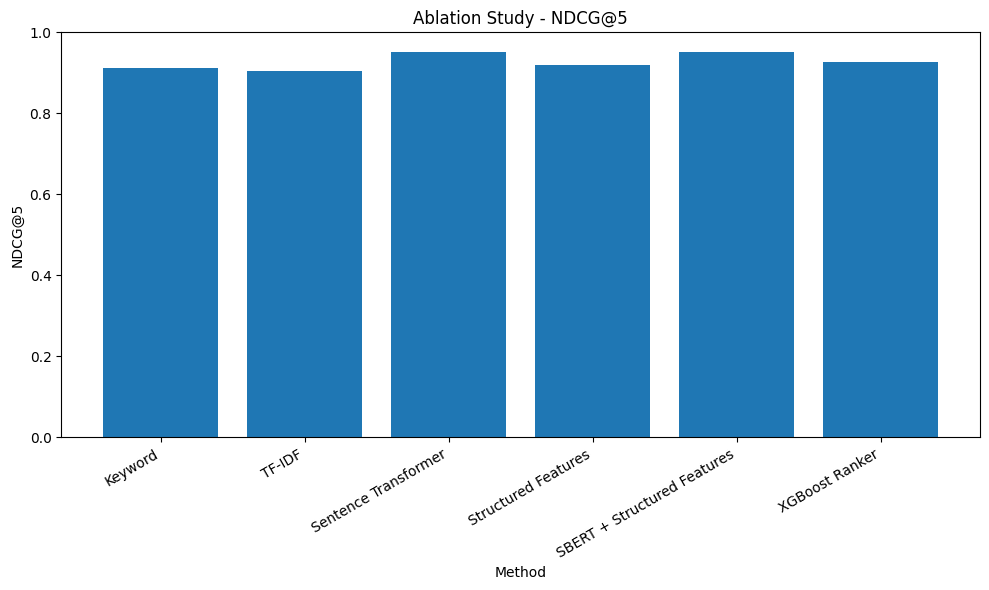

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    ablation_results["method"],
    ablation_results["NDCG@5"]
)

plt.ylabel("NDCG@5")
plt.xlabel("Method")
plt.title("Ablation Study - NDCG@5")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
print(ranker.get_params())

{'objective': 'rank:ndcg', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'ndcg@5', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [ ]:
print([x for x in globals().keys() if "qid" in x.lower() or "group" in x.lower()])

['group_sizes', 'train_groups', 'val_groups', 'test_groups', 'train_qid', 'val_qid', 'test_qid']


In [ ]:
pairwise_ranker = XGBRanker(
    objective="rank:pairwise",
    eval_metric="ndcg@5",
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    enable_categorical=True
)

pairwise_ranker.fit(
    X_train,
    y_train,
    qid=train_qid
)

pairwise_scores = pairwise_ranker.predict(X_test)

pairwise_ndcg, pairwise_mrr = evaluate_ranking(
    y_test,
    pairwise_scores,
    k=5
)

print(f"Pairwise XGBoost NDCG@5: {pairwise_ndcg:.4f}")
print(f"Pairwise XGBoost MRR: {pairwise_mrr:.4f}")

Pairwise XGBoost NDCG@5: 0.9277
Pairwise XGBoost MRR: 1.0000


In [ ]:
#test deeper xgboost model
depth6_ranker = XGBRanker(
    objective="rank:ndcg",
    eval_metric="ndcg@5",
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    enable_categorical=True
)

depth6_ranker.fit(
    X_train,
    y_train,
    qid=train_qid
)

depth6_scores = depth6_ranker.predict(X_test)

depth6_ndcg, depth6_mrr = evaluate_ranking(
    y_test,
    depth6_scores,
    k=5
)

print(f"Depth 6 XGBoost NDCG@5: {depth6_ndcg:.4f}")
print(f"Depth 6 XGBoost MRR: {depth6_mrr:.4f}")

Depth 6 XGBoost NDCG@5: 0.9277
Depth 6 XGBoost MRR: 1.0000


In [ ]:
trees200_ranker = XGBRanker(
    objective="rank:ndcg",
    eval_metric="ndcg@5",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    enable_categorical=True
)

trees200_ranker.fit(
    X_train,
    y_train,
    qid=train_qid
)

trees200_scores = trees200_ranker.predict(X_test)

trees200_ndcg, trees200_mrr = evaluate_ranking(
    y_test,
    trees200_scores,
    k=5
)

print(f"200 Trees XGBoost NDCG@5: {trees200_ndcg:.4f}")
print(f"200 Trees XGBoost MRR: {trees200_mrr:.4f}")

200 Trees XGBoost NDCG@5: 0.9277
200 Trees XGBoost MRR: 1.0000


In [ ]:
tuning_results = pd.DataFrame({
    "configuration": [
        "Baseline rank:ndcg",
        "rank:pairwise",
        "max_depth=6",
        "n_estimators=200"
    ],
    "NDCG@5": [
        xgb_ndcg,
        pairwise_ndcg,
        depth6_ndcg,
        trees200_ndcg
    ],
    "MRR": [
        xgb_mrr,
        pairwise_mrr,
        depth6_mrr,
        trees200_mrr
    ]
})

tuning_results

,configuration,NDCG@5,MRR
0,Baseline rank:ndcg,0.927717,1.0
1,rank:pairwise,0.927717,1.0
2,max_depth=6,0.927717,1.0
3,n_estimators=200,0.927717,1.0


In [ ]:
tuning_results.to_csv(
    f"{PROJECT_PATH}/data/processed/tuning_results.csv",
    index=False
)

print("Tuning results saved successfully")

Tuning results saved successfully


In [ ]:
#sanity test case
easy_job = """
Machine Learning Engineer

Requirements:
Python, Machine Learning, SQL, Pandas,
Scikit-learn, Bachelor's degree in Computer Science,
2 years of experience.
"""

easy_resume = """
Machine Learning Engineer with 3 years of experience.
Expert in Python, Machine Learning, SQL, Pandas and Scikit-learn.
Bachelor's degree in Computer Science.
"""

hard_resume = """
Graphic Designer with 4 years of experience.
Expert in Photoshop, Illustrator, branding and visual design.
Bachelor's degree in Fine Arts.
"""

partial_resume = """
Python Developer with 2 years of experience.
Strong skills in Python and SQL.
Bachelor's degree in Computer Science.
Worked on software development projects.
"""

In [ ]:
#strong smt
easy_features = create_features(
    easy_job,
    easy_resume
)

print("Easy Match Features:")
print(easy_features)

Easy Match Features:
[0.8947368421052632, np.float64(0.9999999999999998), np.float32(0.9117859), 1.0, 1.0, 1.0]


In [ ]:
#weak smt
hard_features = create_features(
    easy_job,
    hard_resume
)

print("Hard Match Features:")
print(hard_features)

Hard Match Features:
[0.3684210526315789, np.float64(0.3551239335176022), np.float32(0.51239824), 0.0, 1.0, 0.5]


In [ ]:
#partial match sanity test
partial_features = create_features(
    easy_job,
    partial_resume
)

print("Partial Match Features:")
print(partial_features)

Partial Match Features:
[0.631578947368421, np.float64(0.23426658736058367), np.float32(0.6963923), 0.5, 1.0, 1.0]


In [ ]:
sanity_features = pd.DataFrame(
    [
        easy_features,
        partial_features,
        hard_features
    ],
    columns=feature_columns
)

sanity_scores = ranker.predict(sanity_features)

sanity_results = pd.DataFrame({
    "candidate": [
        "Strong Match",
        "Partial Match",
        "Weak Match"
    ],
    "xgboost_score": sanity_scores
})

sanity_results = sanity_results.sort_values(
    "xgboost_score",
    ascending=False
).reset_index(drop=True)

sanity_results

,candidate,xgboost_score
0,Strong Match,0.921994
1,Weak Match,-0.152289
2,Partial Match,-0.189035


In [ ]:
sanity_results.to_csv(
    f"{PROJECT_PATH}/data/processed/sanity_test_results.csv",
    index=False
)

print("Sanity test results saved successfully")

Sanity test results saved successfully


In [ ]:
# @title
print("Feature columns:")
for i, col in enumerate(feature_columns, start=1):
    print(f"{i}. {col}")

Feature columns:
1. keyword_score
2. tfidf_score
3. semantic_score
4. skill_match
5. experience_match
6. education_match


In [ ]:
importance = ranker.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": importance
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df

,feature,importance
0,semantic_score,0.545882
1,keyword_score,0.225771
2,tfidf_score,0.165550
3,skill_match,0.062798
4,experience_match,0.000000
5,education_match,0.000000


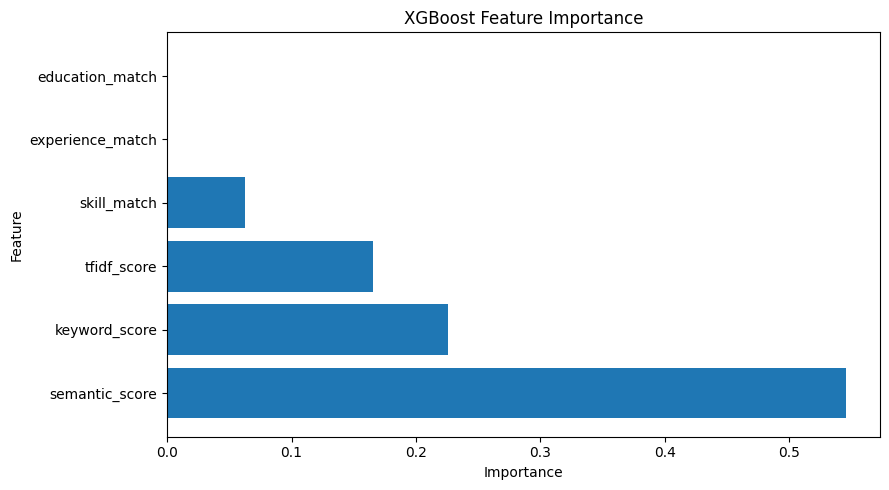

In [ ]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

In [ ]:
feature_importance_df.to_csv(
    f"{PROJECT_PATH}/data/processed/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully")

Feature importance saved successfully


In [ ]:
print(pairs.columns.tolist())

['job_id', 'job_title', 'job_text', 'candidate_id', 'resume_text']


In [ ]:
[x for x in globals().keys() if "rank" in x.lower() or "result" in x.lower()]

['keyword_ranking',
 'tfidf_ranking',
 'baseline_results',
 'semantic_ranking',
 'XGBRanker',
 'ranker',
 'rank_candidates',
 'ranking',
 'rank_candidates_with_evidence',
 'detailed_ranking',
 'new_ranking',
 'evaluate_ranking',
 'evaluation_results',
 'ablation_results',
 'pairwise_ranker',
 'depth6_ranker',
 'trees200_ranker',
 'tuning_results',
 'sanity_results']

In [ ]:
print("detailed_ranking columns:")
print(detailed_ranking.columns.tolist())

print("\nnew_ranking columns:")
print(new_ranking.columns.tolist())

detailed_ranking columns:
['rank', 'candidate_id', 'score', 'skill_match', 'experience_match', 'education_match', 'matched_skills', 'missing_skills']

new_ranking columns:
['rank', 'candidate_id', 'score', 'skill_match', 'experience_match', 'education_match', 'matched_skills', 'missing_skills']


In [ ]:
detailed_ranking

,rank,candidate_id,score,skill_match,experience_match,education_match,matched_skills,missing_skills
0,1,C007,1.452778,0.625,1.0,0.50,"python, machine learning, deep learning, sql, tensorflow","data analysis, pandas, numpy"
1,2,C003,1.381471,0.750,1.0,0.25,"python, machine learning, sql, data analysis, pandas, numpy","deep learning, tensorflow"
2,3,C001,0.801257,0.875,1.0,0.50,"python, machine learning, sql, data analysis, pandas, numpy, tensorflow",deep learning
3,4,C009,-0.178557,0.750,1.0,0.00,"python, machine learning, sql, data analysis, pandas, numpy","deep learning, tensorflow"
4,5,C005,-0.587430,0.375,1.0,0.25,"python, sql, pandas","machine learning, deep learning, data analysis, numpy, tensorflow"
5,6,C004,-1.310142,0.250,1.0,0.50,"python, sql","machine learning, deep learning, data analysis, pandas, numpy, tensorflow"
6,7,C010,-1.353138,0.250,1.0,0.50,"python, sql","machine learning, deep learning, data analysis, pandas, numpy, tensorflow"
7,8,C002,-1.387326,0.125,1.0,0.50,sql,"python, machine learning, deep learning, data analysis, pandas, numpy, tensorflow"
8,9,C006,-1.387326,0.000,1.0,0.50,,"python, machine learning, deep learning, sql, data analysis, pandas, numpy, tensorflow"
9,10,C008,-1.387326,0.125,1.0,0.25,sql,"python, machine learning, deep learning, data analysis, pandas, numpy, tensorflow"


In [ ]:
scores = detailed_ranking["score"].to_numpy()

print("Scores:")
print(scores)

print("\nScores sorted descending:")
print(all(scores[i] >= scores[i + 1] for i in range(len(scores) - 1)))

Scores:
[ 1.4527779   1.3814707   0.8012573  -0.1785565  -0.58742964 -1.310142
 -1.3531381  -1.3873259  -1.3873259  -1.3873259 ]

Scores sorted descending:
True


In [ ]:
detailed_ranking[
    [
        "rank",
        "candidate_id",
        "score",
        "matched_skills",
        "missing_skills"
    ]
]

,rank,candidate_id,score,matched_skills,missing_skills
0,1,C007,1.452778,"python, machine learning, deep learning, sql, tensorflow","data analysis, pandas, numpy"
1,2,C003,1.381471,"python, machine learning, sql, data analysis, pandas, numpy","deep learning, tensorflow"
2,3,C001,0.801257,"python, machine learning, sql, data analysis, pandas, numpy, tensorflow",deep learning
3,4,C009,-0.178557,"python, machine learning, sql, data analysis, pandas, numpy","deep learning, tensorflow"
4,5,C005,-0.587430,"python, sql, pandas","machine learning, deep learning, data analysis, numpy, tensorflow"
5,6,C004,-1.310142,"python, sql","machine learning, deep learning, data analysis, pandas, numpy, tensorflow"
6,7,C010,-1.353138,"python, sql","machine learning, deep learning, data analysis, pandas, numpy, tensorflow"
7,8,C002,-1.387326,sql,"python, machine learning, deep learning, data analysis, pandas, numpy, tensorflow"
8,9,C006,-1.387326,,"python, machine learning, deep learning, sql, data analysis, pandas, numpy, tensorflow"
9,10,C008,-1.387326,sql,"python, machine learning, deep learning, data analysis, pandas, numpy, tensorflow"


In [ ]:
detailed_ranking[
    [
        "rank",
        "candidate_id",
        "score",
        "skill_match",
        "experience_match",
        "education_match",
        "matched_skills",
        "missing_skills"
    ]
]

,rank,candidate_id,score,skill_match,experience_match,education_match,matched_skills,missing_skills
0,1,C007,1.452778,0.625,1.0,0.50,"python, machine learning, deep learning, sql, tensorflow","data analysis, pandas, numpy"
1,2,C003,1.381471,0.750,1.0,0.25,"python, machine learning, sql, data analysis, pandas, numpy","deep learning, tensorflow"
2,3,C001,0.801257,0.875,1.0,0.50,"python, machine learning, sql, data analysis, pandas, numpy, tensorflow",deep learning
3,4,C009,-0.178557,0.750,1.0,0.00,"python, machine learning, sql, data analysis, pandas, numpy","deep learning, tensorflow"
4,5,C005,-0.587430,0.375,1.0,0.25,"python, sql, pandas","machine learning, deep learning, data analysis, numpy, tensorflow"
5,6,C004,-1.310142,0.250,1.0,0.50,"python, sql","machine learning, deep learning, data analysis, pandas, numpy, tensorflow"
6,7,C010,-1.353138,0.250,1.0,0.50,"python, sql","machine learning, deep learning, data analysis, pandas, numpy, tensorflow"
7,8,C002,-1.387326,0.125,1.0,0.50,sql,"python, machine learning, deep learning, data analysis, pandas, numpy, tensorflow"
8,9,C006,-1.387326,0.000,1.0,0.50,,"python, machine learning, deep learning, sql, data analysis, pandas, numpy, tensorflow"
9,10,C008,-1.387326,0.125,1.0,0.25,sql,"python, machine learning, deep learning, data analysis, pandas, numpy, tensorflow"


In [ ]:
detailed_ranking.to_csv(
    f"{PROJECT_PATH}/data/processed/final_ranking_preview.csv",
    index=False
)

print("Final ranking preview saved successfully")

Final ranking preview saved successfully


In [ ]:
member2_summary = pd.DataFrame({
    "component": [
        "Keyword baseline",
        "TF-IDF baseline",
        "Sentence Transformer baseline",
        "Structured features",
        "SBERT + structured features",
        "XGBoost Ranker",
        "NDCG@5 evaluation",
        "MRR evaluation",
        "Feature importance",
        "Sanity testing",
        "Ranking explanations"
    ],
    "status": ["Completed"] * 11
})

member2_summary.to_csv(
    f"{PROJECT_PATH}/data/processed/member2_summary.csv",
    index=False
)

print("Member 2 summary saved successfully")

Member 2 summary saved successfully


In [ ]:
import inspect

print(inspect.signature(rank_candidates_with_evidence))
print(inspect.getsource(rank_candidates_with_evidence))

(job_text, candidates)
def rank_candidates_with_evidence(job_text, candidates):
    results = []

    for _, candidate in candidates.iterrows():
        features = create_features(
            job_text,
            candidate["resume_text"]
        )

        feature_array = np.array(features).reshape(1, -1)

        score = ranker.predict(feature_array)[0]

        matched, missing = get_skill_evidence(
            candidate["resume_text"],
            job_text
        )

        results.append({
            "candidate_id": candidate["candidate_id"],
            "score": score,
            "skill_match": features[3],
            "experience_match": features[4],
            "education_match": features[5],
            "matched_skills": ", ".join(matched),
            "missing_skills": ", ".join(missing)
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        "score",
        ascending=False
    ).reset_index(drop=True)

    results_df["rank"] 

In [ ]:
print(type(ranker))
print(ranker)

<class 'xgboost.sklearn.XGBRanker'>
XGBRanker(base_score=None, booster=None, callbacks=None, colsample_bylevel=None,
          colsample_bynode=None, colsample_bytree=None, device=None,
          early_stopping_rounds=None, enable_categorical=True,
          eval_metric='ndcg@5', feature_types=None, feature_weights=None,
          gamma=None, grow_policy=None, importance_type=None,
          interaction_constraints=None, learning_rate=0.05, max_bin=None,
          max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None,
          max_depth=4, max_leaves=None, min_child_weight=None, missing=nan,
          monotone_constraints=None, multi_strategy=None, n_estimators=100,
          n_jobs=None, num_parallel_tree=None, ...)


In [ ]:
[x for x in globals().keys()
 if any(word in x.lower() for word in ["model", "ranker", "joblib", "pickle"])]

['SENTENCE_MODEL',
 'model',
 'XGBRanker',
 'ranker',
 'MODEL_PATH',
 'EMBEDDING_MODEL_NAME',
 'joblib',
 'model_config',
 'pairwise_ranker',
 'depth6_ranker',
 'trees200_ranker']